# 03 — Dimensionality Reduction

**Goal:** Project 625 defence-system features into 2D to answer:
1. Do ESKAPE species separate by defence-system repertoire?
2. Does ARG burden create visible sub-structure within species clusters?
3. Where does A. baumannii sit relative to the other five species?

**Methods:** PCA (linear), UMAP (non-linear), t-SNE (non-linear, local-focused)

**What this phase does NOT do:** It does not train classifiers or compute
accuracy. Visualisation only. Patterns seen here generate hypotheses that
Phases 6–8 will test quantitatively.

## Imports and data load

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import umap
from sklearn.manifold import TSNE
import warnings
warnings.filterwarnings("ignore")

ROOT    = Path("..")
PROC    = ROOT / "data" / "processed"
FIG_DIR = ROOT / "results" / "figures" / "dimred"
FIG_DIR.mkdir(parents=True, exist_ok=True)

fm = pd.read_parquet(PROC / "feature_matrix.parquet")

LABEL_COLS = ["species", "arg_burden_tertile", "country", "year_bin",
              "complex_member", "sequence_type", "mlst_scheme"]
feat_cols  = [c for c in fm.columns if c not in LABEL_COLS]

# Use only dp_* (binary presence/absence) as features for dimensionality reduction.
# Why not dc_* as well? Because dp_* and dc_* represent the same biology in two
# formats. Including both would double-count defence systems in the distance metric,
# inflating their apparent importance relative to count-only features (IS, ARG counts).
# For visualisation the binary representation is sufficient and cleaner.
dp_cols = [c for c in fm.columns if c.startswith("dp_")]

X = fm[dp_cols].values.astype(float)  # 878 × 274
y_species = fm["species"].values
y_arg     = fm["arg_burden_tertile"].values

SPECIES_ORDER = ["kpneumoniae", "ecloaceae", "abaumannii",
                 "efaecium", "paeruginosa", "saureus"]
SPECIES_LABELS = {
    "kpneumoniae": "K. pneumoniae",
    "ecloaceae":   "E. cloacae",
    "abaumannii":  "A. baumannii",
    "efaecium":    "E. faecium",
    "paeruginosa": "P. aeruginosa",
    "saureus":     "S. aureus",
}
SP_COLORS = {
    "kpneumoniae": "#4878CF",
    "ecloaceae":   "#6ACC65",
    "abaumannii":  "#D65F5F",
    "efaecium":    "#B47CC7",
    "paeruginosa": "#C4AD66",
    "saureus":     "#77BEDB",
}
ARG_COLORS = {"low_ARG": "#4878CF", "mid_ARG": "#AAAAAA", "high_ARG": "#D65F5F"}

print(f"Feature matrix: {fm.shape[0]} genomes × {len(dp_cols)} dp_* features")
print(f"Species: { {sp: (y_species==sp).sum() for sp in SPECIES_ORDER} }")
print(f"ARG tertile: { pd.Series(y_arg).value_counts().to_dict() }")

Feature matrix: 878 genomes × 274 dp_* features
Species: {'kpneumoniae': np.int64(132), 'ecloaceae': np.int64(146), 'abaumannii': np.int64(150), 'efaecium': np.int64(150), 'paeruginosa': np.int64(150), 'saureus': np.int64(150)}
ARG tertile: {'low_ARG': 325, 'high_ARG': 289, 'mid_ARG': 264}


## Section 1 — PCA

PCA finds linear combinations of the 274 dp_* features that explain the most
variance. We run it on **scaled** features (StandardScaler: mean=0, std=1 per
feature). Scaling is necessary because binary features with very different
prevalences (0.01 vs 0.99) would otherwise have very different variances, and
PCA would be dominated by the high-prevalence features regardless of their
biological importance.

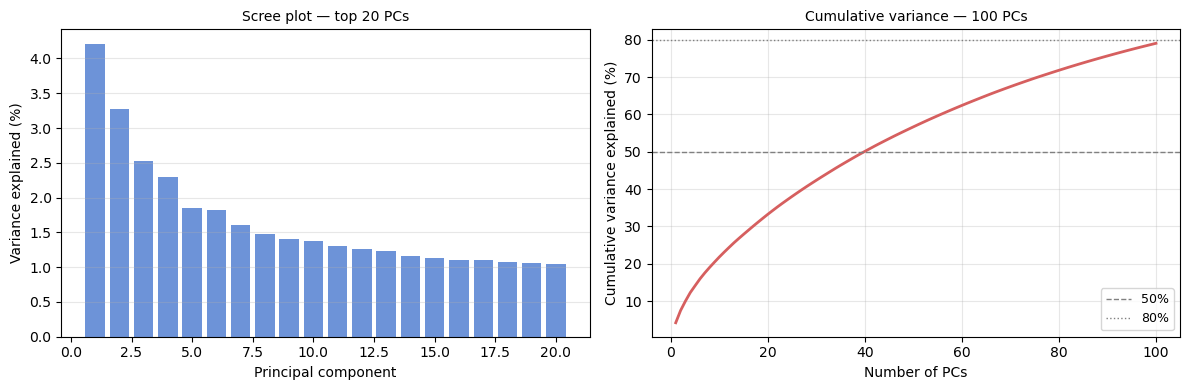

PC1 explains: 4.2%  |  PC2: 3.3%
PCs to reach 50% variance: 40
PCs to reach 80% variance: 101  (max computed: 79.1%)
Saved: results/figures/dimred/01_pca_scree.png


In [2]:
# ── Scale and run PCA (n_components=100 to capture full variance curve) ────────
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Run with 100 components so the cumulative variance curve reaches 80%+
# Only PC1 and PC2 are used in scatter plots — the extra components cost
# nothing for visualisation purposes.
pca = PCA(n_components=100, random_state=42)
X_pca = pca.fit_transform(X_scaled)

# ── Scree plot ────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

cumvar = np.cumsum(pca.explained_variance_ratio_) * 100
indvar = pca.explained_variance_ratio_ * 100

# Left: individual variance per PC (show first 20)
axes[0].bar(range(1, 21), indvar[:20], color="#4878CF", alpha=0.8)
axes[0].set_xlabel("Principal component", fontsize=10)
axes[0].set_ylabel("Variance explained (%)", fontsize=10)
axes[0].set_title("Scree plot — top 20 PCs", fontsize=10)
axes[0].grid(axis="y", alpha=0.3)

# Right: cumulative variance — now showing all 100 PCs
axes[1].plot(range(1, 101), cumvar, color="#D65F5F", lw=2)
axes[1].axhline(50, color="grey", ls="--", lw=1, label="50%")
axes[1].axhline(80, color="grey", ls=":", lw=1, label="80%")
axes[1].set_xlabel("Number of PCs", fontsize=10)
axes[1].set_ylabel("Cumulative variance explained (%)", fontsize=10)
axes[1].set_title("Cumulative variance — 100 PCs", fontsize=10)
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_DIR / "01_pca_scree.png", dpi=150, bbox_inches="tight")
plt.show()

# Use searchsorted only after verifying the value is within the array range
pc_50 = int(np.searchsorted(cumvar, 50)) + 1
pc_80 = int(np.searchsorted(cumvar, 80)) + 1
print(f"PC1 explains: {indvar[0]:.1f}%  |  PC2: {indvar[1]:.1f}%")
print(f"PCs to reach 50% variance: {pc_50}")
print(f"PCs to reach 80% variance: {pc_80}  (max computed: {cumvar[-1]:.1f}%)")
print("Saved: results/figures/dimred/01_pca_scree.png")

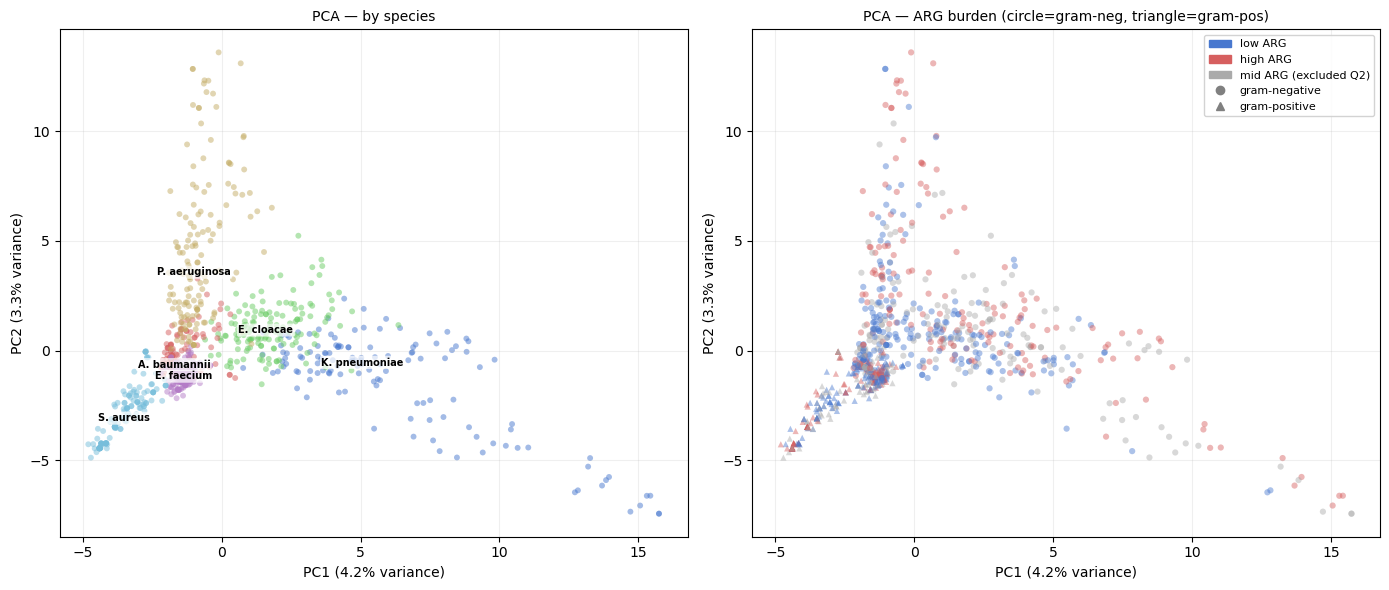

Saved: results/figures/dimred/02_pca_scatter.png


In [3]:
# ── PCA scatter — coloured by species ────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, color_by in zip(axes, ["species", "arg"]):
    emb = X_pca  # reuse variable name for the label snippet
    for sp in SPECIES_ORDER:
        mask = y_species == sp
        ax.scatter(
            X_pca[mask, 0], X_pca[mask, 1],
            c=SP_COLORS[sp], alpha=0.5, s=18, edgecolors="none",
            label=SPECIES_LABELS[sp],
        )
    ax.set_xlabel(f"PC1 ({indvar[0]:.1f}% variance)", fontsize=10)
    ax.set_ylabel(f"PC2 ({indvar[1]:.1f}% variance)", fontsize=10)
    ax.grid(alpha=0.2)

# Panel A labels
ax = axes[0]
emb = X_pca
for sp in SPECIES_ORDER:
    mask = y_species == sp
    cx = np.median(emb[mask, 0])
    cy = np.median(emb[mask, 1])
    ax.text(cx, cy, SPECIES_LABELS[sp],
            fontsize=7, fontweight="bold", color="black",
            ha="center", va="center",
            bbox=dict(boxstyle="round,pad=0.15", fc="white", alpha=0.7, ec="none"))
axes[0].set_title("PCA — by species", fontsize=10)

# Panel B: colour by ARG burden, shape by gram stain
gram_neg = {"kpneumoniae", "ecloaceae", "abaumannii", "paeruginosa"}
axes[1].cla()
for i in range(len(y_species)):
    sp = y_species[i]
    arg = y_arg[i]
    if arg not in ARG_COLORS:
        continue
    marker = "o" if sp in gram_neg else "^"
    axes[1].scatter(
        X_pca[i, 0], X_pca[i, 1],
        c=ARG_COLORS[arg], alpha=0.45, s=20,
        marker=marker, edgecolors="none",
    )
axes[1].set_xlabel(f"PC1 ({indvar[0]:.1f}% variance)", fontsize=10)
axes[1].set_ylabel(f"PC2 ({indvar[1]:.1f}% variance)", fontsize=10)
axes[1].set_title("PCA — ARG burden (circle=gram-neg, triangle=gram-pos)", fontsize=10)
axes[1].grid(alpha=0.2)

legend_patches = [
    mpatches.Patch(color=ARG_COLORS["low_ARG"],  label="low ARG"),
    mpatches.Patch(color=ARG_COLORS["high_ARG"], label="high ARG"),
    mpatches.Patch(color=ARG_COLORS["mid_ARG"],  label="mid ARG (excluded Q2)"),
    plt.Line2D([0],[0], marker="o", color="grey", lw=0, label="gram-negative"),
    plt.Line2D([0],[0], marker="^", color="grey", lw=0, label="gram-positive"),
]
axes[1].legend(handles=legend_patches, fontsize=8, framealpha=0.85)

plt.tight_layout()
plt.savefig(FIG_DIR / "02_pca_scatter.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: results/figures/dimred/02_pca_scatter.png")

In [4]:
# ── PCA loadings: what drives PC1 and PC2? ────────────────────────────────────
loadings = pd.DataFrame(
    pca.components_[:2].T,
    index=[c.replace("dp_", "") for c in dp_cols],
    columns=["PC1", "PC2"],
)

print("Top 10 features driving PC1 (positive = pushes genomes to the right):")
print(loadings["PC1"].abs().nlargest(10).index.tolist())
print()
print("PC1 — top 5 positive (push right):")
print(loadings["PC1"].nlargest(5).to_string())
print()
print("PC1 — top 5 negative (push left):")
print(loadings["PC1"].nsmallest(5).to_string())
print()
print("Top 5 features driving PC2:")
print(loadings["PC2"].abs().nlargest(5).index.tolist())

Top 10 features driving PC1 (positive = pushes genomes to the right):
['padloc_PDC-S12', 'VSPR', 'padloc_PDC-S13', 'df_Mok_Hok_Sok', 'PD-T4-3', 'df_GAPS1', 'df_DS-24', 'df_PD-T7-1', 'df_SDIC3', 'AbiU']

PC1 — top 5 positive (push right):
padloc_PDC-S12    0.226156
VSPR              0.222339
padloc_PDC-S13    0.195186
df_Mok_Hok_Sok    0.190073
PD-T4-3           0.188727

PC1 — top 5 negative (push left):
df_gcu233        -0.138801
df_Abi2          -0.132006
df_FS_Sma        -0.129682
padloc_PDC-M24   -0.122436
Dodola           -0.085623

Top 5 features driving PC2:
['PD-T4-6', 'padloc_PDC-M30', 'padloc_PDC-S02', 'Wadjet_I', 'df_RloC']


## Section 2 — UMAP

UMAP preserves neighbourhood relationships (similar genomes stay close in 2D).
Unlike PCA, it can reveal curved or nested cluster structure.

**Two parameters matter most:**
- `n_neighbors`: how many neighbours each point considers when building the
  graph. Low value (~5) = focus on very local structure (tight clusters, may
  fragment). High value (~50) = focus on global structure (spread-out, smoother).
- `min_dist`: how tightly points are packed within a cluster. Low = tight;
  high = spread.

We run with `random_state=42` for reproducibility. Then we do a sensitivity
check to confirm the main structure is not an artefact of parameter choice.

In [5]:
# ── UMAP default run ──────────────────────────────────────────────────────────
# Run UMAP on the scaled binary feature matrix
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=2,
                    metric="jaccard",   # appropriate for binary P/A data
                    random_state=42, verbose=False)
X_umap = reducer.fit_transform(X)

print("UMAP embedding computed.")
print(f"Embedding shape: {X_umap.shape}")

UMAP embedding computed.
Embedding shape: (878, 2)


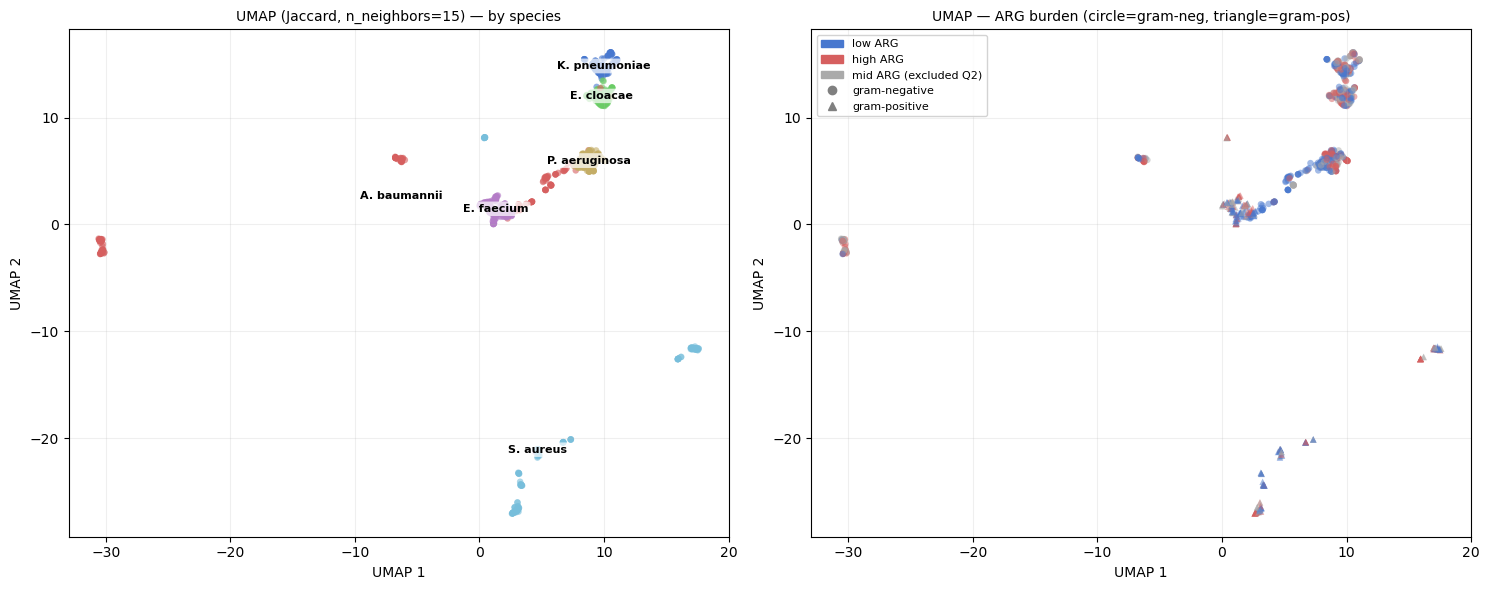

Saved: results/figures/dimred/03_umap_scatter.png


In [6]:
# ── UMAP scatter — species and ARG burden ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# ── Panel A: colour by species, label cluster centroids ──────────────────────
ax = axes[0]
for sp in SPECIES_ORDER:
    mask = y_species == sp
    ax.scatter(
        X_umap[mask, 0], X_umap[mask, 1],
        c=SP_COLORS[sp], alpha=0.6, s=22, edgecolors="none",
        label=SPECIES_LABELS[sp],
    )

for sp in SPECIES_ORDER:
    mask = y_species == sp
    cx = np.median(X_umap[mask, 0])
    cy = np.median(X_umap[mask, 1])
    ax.text(cx, cy, SPECIES_LABELS[sp],
            fontsize=8, fontweight="bold", color="black",
            ha="center", va="center",
            bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.7, ec="none"))

ax.set_title("UMAP (Jaccard, n_neighbors=15) — by species", fontsize=10)
ax.set_xlabel("UMAP 1", fontsize=10)
ax.set_ylabel("UMAP 2", fontsize=10)
ax.grid(alpha=0.2)

# ── Panel B: colour by ARG burden, shape by gram stain (no text labels) ──────
ax2 = axes[1]
gram_neg = {"kpneumoniae", "ecloaceae", "abaumannii", "paeruginosa"}
for i in range(len(y_species)):
    sp = y_species[i]
    arg = y_arg[i]
    if arg not in ARG_COLORS:
        continue
    marker = "o" if sp in gram_neg else "^"
    ax2.scatter(
        X_umap[i, 0], X_umap[i, 1],
        c=ARG_COLORS[arg], alpha=0.5, s=22,
        marker=marker, edgecolors="none",
    )

legend_patches = [
    mpatches.Patch(color=ARG_COLORS["low_ARG"],  label="low ARG"),
    mpatches.Patch(color=ARG_COLORS["high_ARG"], label="high ARG"),
    mpatches.Patch(color=ARG_COLORS["mid_ARG"],  label="mid ARG (excluded Q2)"),
    plt.Line2D([0],[0], marker="o", color="grey", lw=0, label="gram-negative"),
    plt.Line2D([0],[0], marker="^", color="grey", lw=0, label="gram-positive"),
]
ax2.legend(handles=legend_patches, fontsize=8, framealpha=0.85)
ax2.set_title("UMAP — ARG burden (circle=gram-neg, triangle=gram-pos)", fontsize=10)
ax2.set_xlabel("UMAP 1", fontsize=10)
ax2.set_ylabel("UMAP 2", fontsize=10)
ax2.grid(alpha=0.2)

plt.tight_layout()
plt.savefig(FIG_DIR / "03_umap_scatter.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: results/figures/dimred/03_umap_scatter.png")

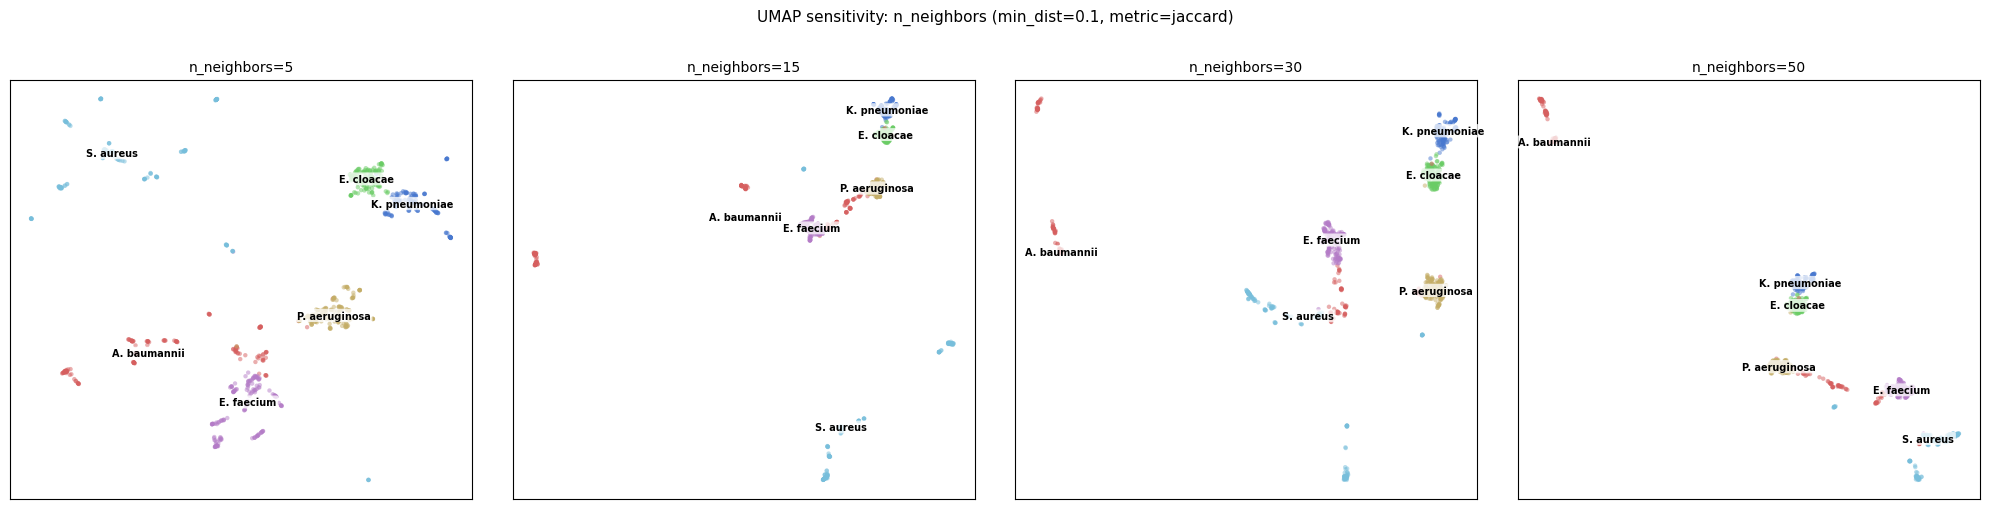

Saved: results/figures/dimred/04_umap_sensitivity.png


In [7]:
# ── UMAP parameter sensitivity: n_neighbors sweep ────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
fig.suptitle("UMAP sensitivity: n_neighbors (min_dist=0.1, metric=jaccard)",
             fontsize=11, y=1.01)

for ax, nn in zip(axes, [5, 15, 30, 50]):
    emb = umap.UMAP(n_neighbors=nn, min_dist=0.1, n_components=2,
                    metric="jaccard", random_state=42, verbose=False
                   ).fit_transform(X)
    for sp in SPECIES_ORDER:
        mask = y_species == sp
        ax.scatter(emb[mask, 0], emb[mask, 1],
                   c=SP_COLORS[sp], alpha=0.5, s=10, edgecolors="none")
    # Full species name labels at cluster median
    for sp in SPECIES_ORDER:
        mask = y_species == sp
        cx = np.median(emb[mask, 0])
        cy = np.median(emb[mask, 1])
        ax.text(cx, cy, SPECIES_LABELS[sp],
                fontsize=7, fontweight="bold", color="black",
                ha="center", va="center",
                bbox=dict(boxstyle="round,pad=0.15", fc="white", alpha=0.75, ec="none"))
    ax.set_title(f"n_neighbors={nn}", fontsize=10)
    ax.set_xticks([]); ax.set_yticks([])

plt.tight_layout()
plt.savefig(FIG_DIR / "04_umap_sensitivity.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: results/figures/dimred/04_umap_sensitivity.png")

## Section 3 — t-SNE

t-SNE is run for comparison only. Key differences from UMAP:
- More aggressive at compressing within-cluster distances
- Distances between clusters are not interpretable at all
- Slower; more sensitive to `perplexity` (analogous to n_neighbors)

We run with perplexity=30 (standard default) and compare to UMAP.

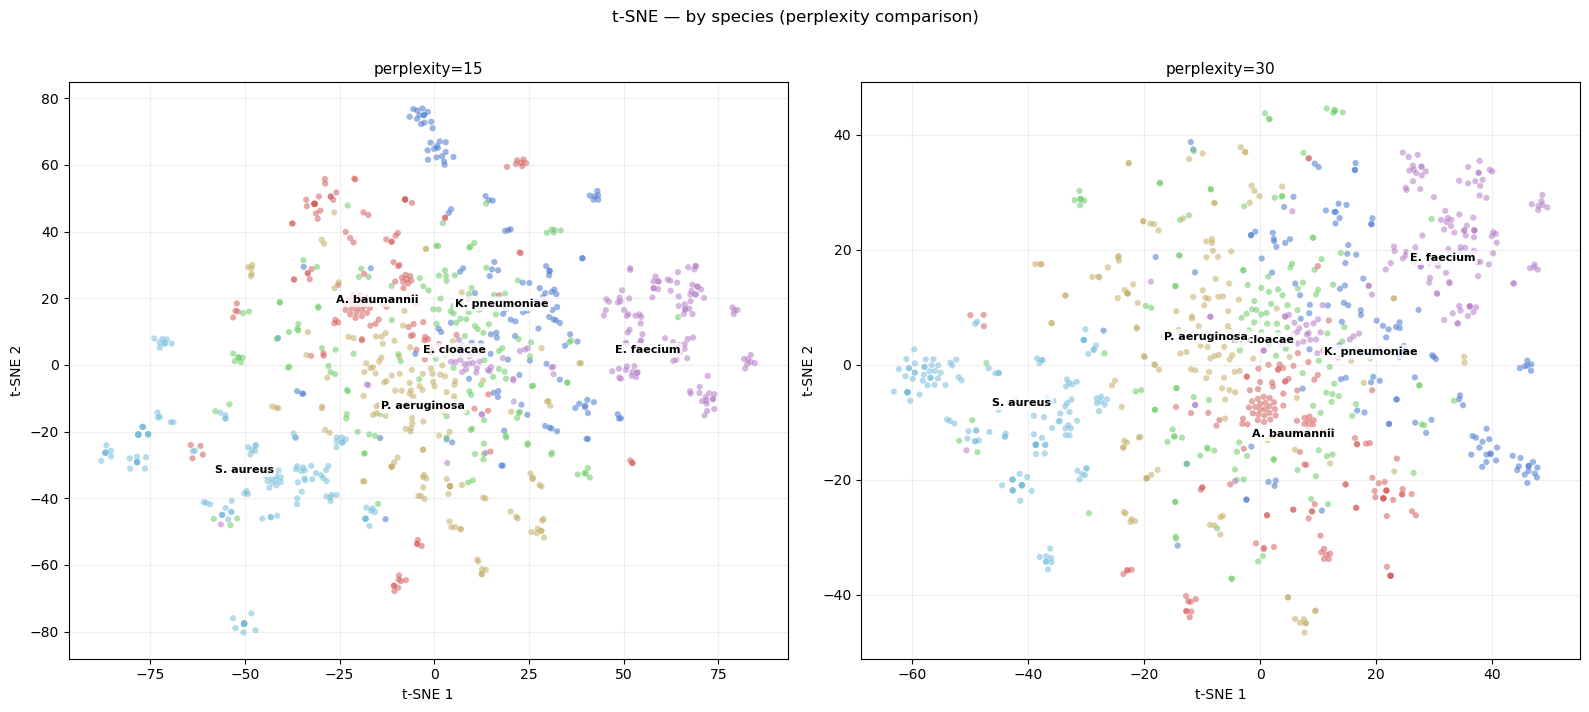

Saved: results/figures/dimred/05_tsne_scatter.png


In [8]:
# ── t-SNE run — two perplexity values side by side ───────────────────────────
# perplexity is t-SNE's equivalent of n_neighbors in UMAP:
# low perplexity = focus on tight local clusters
# high perplexity = looser, more global structure
# Standard default is 30; we show 15 alongside for comparison.

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle("t-SNE — by species (perplexity comparison)", fontsize=12, y=1.01)

for ax, perp in zip(axes, [15, 30]):
    tsne = TSNE(n_components=2, perplexity=perp, random_state=42,
                learning_rate="auto", init="pca", n_jobs=-1)
    X_tsne = tsne.fit_transform(X_scaled)

    for sp in SPECIES_ORDER:
        mask = y_species == sp
        ax.scatter(X_tsne[mask, 0], X_tsne[mask, 1],
                   c=SP_COLORS[sp], alpha=0.55, s=20, edgecolors="none",
                   label=SPECIES_LABELS[sp])

    # Centroid labels
    for sp in SPECIES_ORDER:
        mask = y_species == sp
        cx = np.median(X_tsne[mask, 0])
        cy = np.median(X_tsne[mask, 1])
        ax.text(cx, cy, SPECIES_LABELS[sp],
                fontsize=8, fontweight="bold", color="black",
                ha="center", va="center",
                bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.80, ec="none"))

    ax.set_title(f"perplexity={perp}", fontsize=11)
    ax.set_xlabel("t-SNE 1", fontsize=10)
    ax.set_ylabel("t-SNE 2", fontsize=10)
    ax.grid(alpha=0.2)

plt.tight_layout()
plt.savefig(FIG_DIR / "05_tsne_scatter.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: results/figures/dimred/05_tsne_scatter.png")

## Comprehension check — Phase 5

**Q1.** In the PCA scree plot, PC1 explains a certain percentage of variance and
PC2 explains less. If you needed 20 PCs to explain 80% of the variance, what
would that tell you about the structure of the defence-system feature space?

**Q2.** UMAP uses `metric="jaccard"` for the binary presence/absence features.
From what you learned in Phase 3 about distance metrics on sparse binary data,
why is Jaccard more appropriate here than Euclidean distance?

**Q3.** You notice that KP and EC partially overlap in both PCA and UMAP.
Give two reasons — one biological, one technical — why this overlap is expected
and does not mean the Q1 classifier will fail to separate them.